In [3]:
from google.colab import files
uploaded = files.upload()

Saving away_team.csv to away_team.csv
Saving away_team_score.csv to away_team_score.csv
Saving event.csv to event.csv
Saving home_team.csv to home_team.csv
Saving home_team_score.csv to home_team_score.csv
Saving odds.csv to odds.csv
Saving pbp.csv to pbp.csv
Saving power.csv to power.csv
Saving round.csv to round.csv
Saving season.csv to season.csv
Saving statistics.csv to statistics.csv
Saving time.csv to time.csv
Saving tournament.csv to tournament.csv
Saving venue.csv to venue.csv
Saving votes.csv to votes.csv


In [4]:
import pandas as pd

#uploaded file
files = {
    'event': 'event.csv',
    'home_team': 'home_team.csv',
    'away_team': 'away_team.csv',
    'home_team_score': 'home_team_score.csv',
    'away_team_score': 'away_team_score.csv',
    'time': 'time.csv',
    'tournament': 'tournament.csv',
    'venue': 'venue.csv',
    'votes': 'votes.csv',
    'round': 'round.csv',
    'season': 'season.csv',
    'odds': 'odds.csv',
    'power': 'power.csv',
}

data = {name: pd.read_csv(path) for name, path in files.items()}

#clean def
def dedupe_one_per_match(df, id_col='match_id'):
    # tekrari ha delete
    df = df.drop_duplicates()
    df = df.assign(_null_count=df.isnull().sum(axis=1))
    df = df.sort_values('_null_count').drop_duplicates(subset=id_col, keep='first')
    df = df.drop(columns='_null_count').reset_index(drop=True)
    return df

one_row_per_match = ['event', 'home_team', 'away_team', 'home_team_score',
                      'away_team_score', 'time', 'tournament', 'venue',
                      'votes', 'round', 'season']

for name in one_row_per_match:
    before = len(data[name])
    data[name] = dedupe_one_per_match(data[name])
    print(f"{name}: {before} -> {len(data[name])}")


for name in ['odds', 'power']:
    before = len(data[name])
    data[name] = data[name].drop_duplicates().reset_index(drop=True)
    print(f"{name}: {before} -> {len(data[name])}")

#normalys
data['round']['name'] = data['round']['name'].str.strip()
data['round']['name'] = data['round']['name'].replace({
    'Semifinals': 'Semifinal',
    'Quarterfinals': 'Quarterfinal',
})

data['event']['start_datetime'] = pd.to_datetime(data['event']['start_datetime'], unit='s')
data['home_team']['height'] = pd.to_numeric(data['home_team']['height'], errors='coerce')
data['away_team']['height'] = pd.to_numeric(data['away_team']['height'], errors='coerce')
data['home_team']['current_rank'] = pd.to_numeric(data['home_team']['current_rank'], errors='coerce')
data['away_team']['current_rank'] = pd.to_numeric(data['away_team']['current_rank'], errors='coerce')


for name, df in data.items():
    df.to_csv(f'{name}_clean.csv', index=False)

event: 35053 -> 16873
home_team: 25610 -> 12389
away_team: 24203 -> 11690
home_team_score: 35164 -> 16873
away_team_score: 35053 -> 16873
time: 35671 -> 16873
tournament: 35671 -> 16873
venue: 35423 -> 16749
votes: 35658 -> 16873
round: 19283 -> 9243
season: 35671 -> 16873
odds: 60946 -> 34807
power: 469677 -> 249587


**Qurstion9**

In [10]:
import pandas as pd

# amadesazi va etebar sanji
rounds = data['round'].copy()
rounds['name'] = rounds['name'].str.strip()
print("Unique round names:", rounds['name'].unique())

finals = rounds[rounds['name'] == 'Final'].copy()
print(f"Total final rows: {len(finals)}")
print(f"Unique match_id in finals: {finals['match_id'].nunique()}")

#baresi natayej va connect krdn be event
finals = finals.merge(
    data['event'][['match_id', 'winner_code', 'start_datetime']],
    on='match_id', how='left'
)
missing_winner = finals['winner_code'].isnull().sum()
print(f"Finals missing winner_code: {missing_winner}")
finals = finals.dropna(subset=['winner_code', 'start_datetime'])
finals['winner_code'] = finals['winner_code'].astype(int)

invalid_codes = finals[~finals['winner_code'].isin([1, 2])]
print(f"Invalid winner_code values: {len(invalid_codes)}")
finals = finals[finals['winner_code'].isin([1, 2])]

# connect be tournoment
finals = finals.merge(
    data['tournament'][['match_id', 'tournament_id', 'tournament_name', 'tournament_category_name']],
    on='match_id', how='inner'
)
name_check = finals.groupby('tournament_id')['tournament_name'].nunique()
print(f"tournament_id with more than one name: {(name_check > 1).sum()}")

# connect ba player_id va country
home_players = data['home_team'][['match_id', 'name', 'player_id', 'country']].rename(
    columns={'name': 'home_name', 'player_id': 'home_pid', 'country': 'home_country'})
away_players = data['away_team'][['match_id', 'name', 'player_id', 'country']].rename(
    columns={'name': 'away_name', 'player_id': 'away_pid', 'country': 'away_country'})

finals = finals.merge(home_players, on='match_id', how='left')
finals = finals.merge(away_players, on='match_id', how='left')

missing_home = finals['home_pid'].isnull().sum()
missing_away = finals['away_pid'].isnull().sum()
print(f"Finals missing home player_id: {missing_home}")
print(f"Finals missing away player_id: {missing_away}")

#winner
finals['winner_pid'] = finals.apply(lambda r: r['home_pid'] if r['winner_code'] == 1 else r['away_pid'], axis=1)
finals['winner_name'] = finals.apply(lambda r: r['home_name'] if r['winner_code'] == 1 else r['away_name'], axis=1)
finals['winner_country'] = finals.apply(lambda r: r['home_country'] if r['winner_code'] == 1 else r['away_country'], axis=1)
finals = finals.dropna(subset=['winner_pid'])
finals['winner_pid'] = finals['winner_pid'].astype(int)

name_pid_map = finals.groupby('winner_name')['winner_pid'].nunique()
ambiguous_names = name_pid_map[name_pid_map > 1]
print(f"Player names mapped to multiple player_ids: {len(ambiguous_names)}")

# hazf tournoment tekrari
finals['year_month'] = finals['start_datetime'].dt.to_period('M')
before = len(finals)
finals = finals.drop_duplicates(subset=['tournament_id'])
print(f"Duplicate tournament finals removed: {before} -> {len(finals)}")

# group
q9_by_pid = (
    finals.groupby(['winner_pid', 'winner_name', 'winner_country', 'year_month'])['tournament_id']
    .nunique()
    .reset_index(name='tournaments_won')
    .sort_values('tournaments_won', ascending=False)
)
print("\nTop 10 rows:")
print(q9_by_pid.head(10))

# taybreak
max_count = q9_by_pid['tournaments_won'].max()
top_players = q9_by_pid[q9_by_pid['tournaments_won'] == max_count].copy()
print(f"\nNumber of players tied at {max_count} wins: {len(top_players)}")


top_players = top_players.sort_values(['year_month', 'winner_pid'])
winner_row = top_players.iloc[0]

# list tournoment haye barande
winner_tourneys = finals[
    (finals['winner_pid'] == winner_row['winner_pid']) &
    (finals['year_month'] == winner_row['year_month'])
]['tournament_name'].tolist()

# qverall answer
print("\n" + "="*75)
print("OVERALL ANSWER")
print("="*75)
print(f"Player  : {winner_row['winner_name']}")
print(f"Country : {winner_row['winner_country']}")
print(f"Month   : {winner_row['year_month']}")
print(f"Wins    : {winner_row['tournaments_won']}")
print(f"Tourneys: {', '.join(winner_tourneys)}")

Unique round names: ['Round of 16' 'Quarterfinal' 'Round of 32' 'Semifinal' 'Final'
 'Qualification round 2' 'Qualification round 1' 'Round of 64'
 'Round of 128']
Total final rows: 260
Unique match_id in finals: 260
Finals missing winner_code: 3
Invalid winner_code values: 0
tournament_id with more than one name: 0
Finals missing home player_id: 7
Finals missing away player_id: 4
Player names mapped to multiple player_ids: 0
Duplicate tournament finals removed: 252 -> 252

Top 10 rows:
     winner_pid         winner_name  winner_country year_month  \
14        50901            Popko D.      Kazakhstan    2024-02   
76       152766            Helgo M.          Norway    2024-03   
135      230049            Jianu F.         Romania    2024-03   
107      202572           Gengel M.  Czech Republic    2024-02   
196      372311            Nicod J.  Czech Republic    2024-03   
188      341818            Faria J.        Portugal    2024-03   
58       111857             Ursu V.         Uk

**Question10**

In [11]:
import pandas as pd

# tarkib home va away ba id ha
cols = ['player_id', 'name', 'height', 'current_rank', 'gender', 'country']
players_raw = pd.concat([data['home_team'][cols], data['away_team'][cols]], ignore_index=True)
print(f"Total rows before dedup: {len(players_raw)}")

# tekrari nbodn
dup_check = players_raw.groupby('player_id')[['height', 'current_rank']].nunique()
inconsistent = dup_check[(dup_check['height'] > 1) | (dup_check['current_rank'] > 1)]
print(f"Players with conflicting height/rank across rows: {len(inconsistent)}")

# kamratin null braye bazikon tekrari(kameltarin)
players_raw = players_raw.assign(_nulls=players_raw.isnull().sum(axis=1))
players = players_raw.sort_values('_nulls').drop_duplicates(subset='player_id', keep='first')
players = players.drop(columns='_nulls').reset_index(drop=True)
print(f"Unique players: {len(players)}")

# maghadi gomshode
print(f"Missing height: {players['height'].isnull().sum()}")
print(f"Missing rank: {players['current_rank'].isnull().sum()}")

players = players.dropna(subset=['height', 'current_rank'])
print(f"After dropping nulls: {len(players)} players")

# maghadir part va shenasaee tozie
print("\nHeight describe:")
print(players['height'].describe())
print("\nRank describe:")
print(players['current_rank'].describe())

# ghad byd bein 1.4 ta 2.3 bshe (vaghe binane)
height_outliers = players[(players['height'] <= 1.4) | (players['height'] >= 2.3)]
print(f"\nHeight outliers: {len(height_outliers)}")
if len(height_outliers) > 0:
    print(height_outliers[['name', 'height', 'current_rank']])

players_clean = players[(players['height'] > 1.4) & (players['height'] < 2.3)]

# rank manfi ya sefr manteghi ni
rank_outliers = players_clean[players_clean['current_rank'] <= 0]
print(f"Rank outliers (<=0): {len(rank_outliers)}")
players_clean = players_clean[players_clean['current_rank'] > 0]

print(f"\nFinal player count for analysis: {len(players_clean)}")

#duplicate player id byd 0 bshe
final_dup = players_clean['player_id'].duplicated().sum()
print(f"Duplicate player_id remaining: {final_dup}")

# hambastegi va tafkik jensiat
overall_corr = players_clean['height'].corr(players_clean['current_rank'])
overall_n = len(players_clean)

gender_results = {}
for g in players_clean['gender'].dropna().unique():
    sub = players_clean[players_clean['gender'] == g]
    gender_results[g] = {'corr': sub['height'].corr(sub['current_rank']), 'n': len(sub)}

print("\nCorrelation by gender:")
for g, r in gender_results.items():
    print(f"  {g}: corr={r['corr']:.4f}, n={r['n']}")

# hambastegi
abs_corr = abs(overall_corr)
if abs_corr < 0.1:
    strength = "negligible / almost none"
elif abs_corr < 0.3:
    strength = "weak"
elif abs_corr < 0.5:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if overall_corr > 0 else "negative"

# overall answer
print("\n" + "="*75)
print("OVERALL ANSWER")
print("="*75)
print(f"Players analyzed : {overall_n}")
print(f"Correlation (r)  : {overall_corr:.4f}")
print(f"Direction        : {direction}")
print(f"Strength         : {strength}")
for g, r in gender_results.items():
    print(f"  - {g}: r={r['corr']:.4f} (n={r['n']})")

q10_clean = players_clean[['player_id', 'name', 'height', 'current_rank', 'gender', 'country']]

Total rows before dedup: 24079
Players with conflicting height/rank across rows: 2153
Unique players: 2644
Missing height: 1295
Missing rank: 60
After dropping nulls: 1340 players

Height describe:
count    1340.000000
mean        1.821716
std         0.080534
min         1.570000
25%         1.780000
50%         1.830000
75%         1.880000
max         2.080000
Name: height, dtype: float64

Rank describe:
count    1340.000000
mean      584.683582
std       449.758485
min         1.000000
25%       195.000000
50%       476.500000
75%       896.000000
max      1858.000000
Name: current_rank, dtype: float64

Height outliers: 0
Rank outliers (<=0): 0

Final player count for analysis: 1340
Duplicate player_id remaining: 0

Correlation by gender:
  F: corr=-0.1847, n=253
  M: corr=-0.1091, n=1086

OVERALL ANSWER
Players analyzed : 1340
Correlation (r)  : 0.1080
Direction        : positive
Strength         : weak
  - F: r=-0.1847 (n=253)
  - M: r=-0.1091 (n=1086)


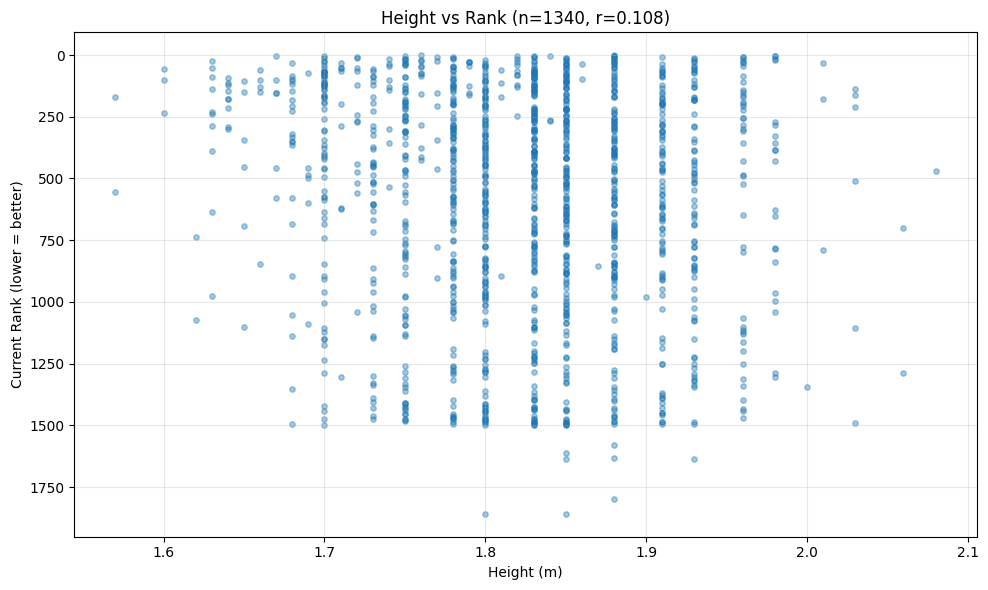

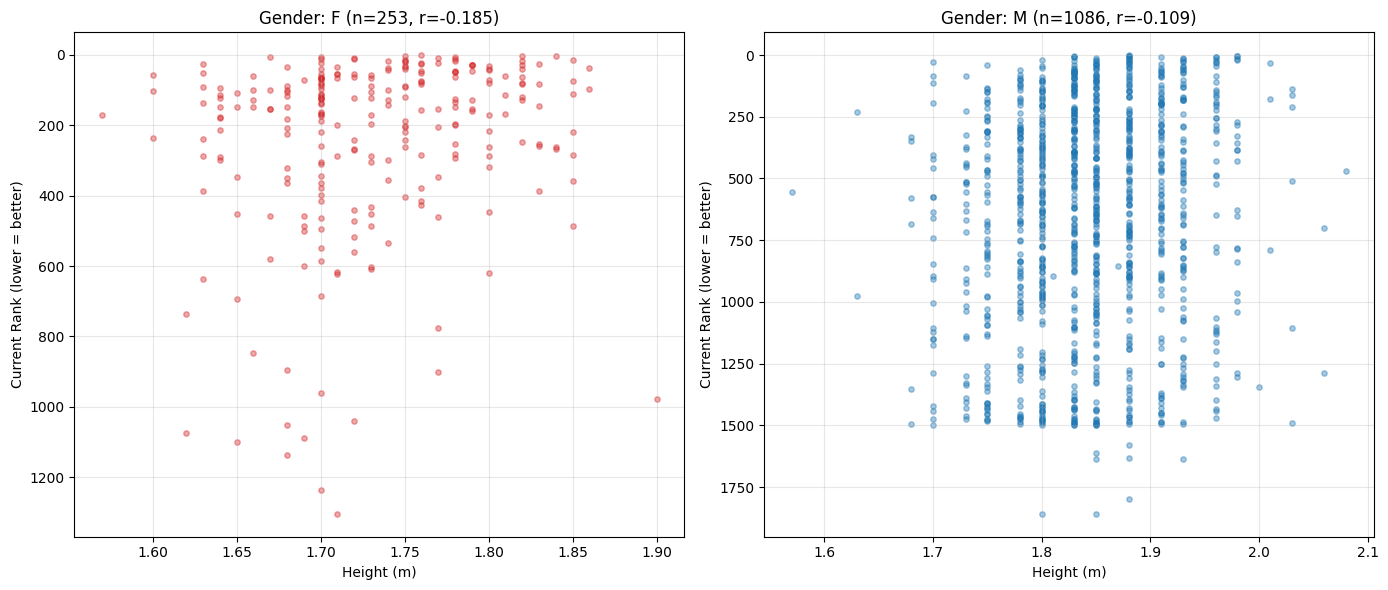

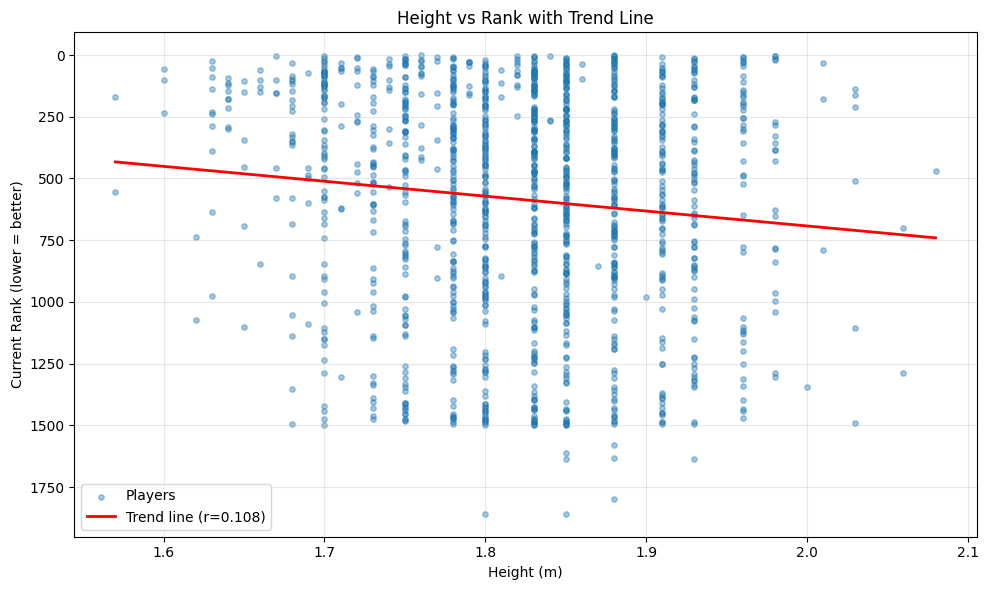

In [12]:
import matplotlib.pyplot as plt

#nemodar parakandegi koli
plt.figure(figsize=(10, 6))
plt.scatter(players_clean['height'], players_clean['current_rank'], alpha=0.4, s=15)
plt.xlabel('Height (m)')
plt.ylabel('Current Rank (lower = better)')
plt.title(f'Height vs Rank (n={len(players_clean)}, r={overall_corr:.3f})')

# behratin rank balatarine
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('height_vs_rank_overall.png', dpi=150)
plt.show()

# braye har jensiat
genders = players_clean['gender'].dropna().unique()
fig, axes = plt.subplots(1, len(genders), figsize=(7 * len(genders), 6))
if len(genders) == 1:
    axes = [axes]

for ax, g in zip(axes, genders):
    sub = players_clean[players_clean['gender'] == g]
    corr_g = sub['height'].corr(sub['current_rank'])
    ax.scatter(sub['height'], sub['current_rank'], alpha=0.4, s=15, color='tab:blue' if g == 'M' else 'tab:red')
    ax.set_xlabel('Height (m)')
    ax.set_ylabel('Current Rank (lower = better)')
    ax.set_title(f'Gender: {g} (n={len(sub)}, r={corr_g:.3f})')
    ax.invert_yaxis()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('height_vs_rank_by_gender.png', dpi=150)
plt.show()

# nemodar koli ba khaat ravand
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(players_clean['height'], players_clean['current_rank'], alpha=0.4, s=15, label='Players')

z = np.polyfit(players_clean['height'], players_clean['current_rank'], 1)
trend_line = np.poly1d(z)
x_range = np.linspace(players_clean['height'].min(), players_clean['height'].max(), 100)
plt.plot(x_range, trend_line(x_range), color='red', linewidth=2, label=f'Trend line (r={overall_corr:.3f})')

plt.xlabel('Height (m)')
plt.ylabel('Current Rank (lower = better)')
plt.title('Height vs Rank with Trend Line')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('height_vs_rank_trendline.png', dpi=150)
plt.show()

there is no meaningful relationship between height and ranking.

**Question11**

In [16]:
import pandas as pd

#time
period_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']
time_df = data['time'][['match_id'] + period_cols].copy()

for col in period_cols:
    time_df.loc[time_df[col] < 0, col] = None

time_df['total_seconds'] = time_df[period_cols].sum(axis=1, skipna=True)
time_df['n_sets_played'] = time_df[period_cols].notnull().sum(axis=1)
time_df = time_df[time_df['n_sets_played'] > 0].copy()
time_df['total_minutes'] = time_df['total_seconds'] / 60
time_df['total_hours'] = time_df['total_seconds'] / 3600

outliers = time_df[(time_df['total_minutes'] < 15) | (time_df['total_minutes'] > 360)]
print(f"Unrealistic duration outliers removed: {len(outliers)}")
time_clean = time_df[(time_df['total_minutes'] >= 15) & (time_df['total_minutes'] <= 360)].copy()
print(f"Matches after outlier removal: {len(time_clean)}")

# find longest match
top10 = time_clean.sort_values('total_minutes', ascending=False).head(10)
print("\nTop 10 longest matches:")
print(top10[['match_id', 'total_minutes', 'total_hours']])

longest_match_id = top10.iloc[0]['match_id']

# winner
event_info = data['event'][data['event']['match_id'] == longest_match_id][['match_id', 'winner_code']]
winner_code = event_info['winner_code'].values[0] if len(event_info) > 0 else None
print(f"\nWinner code for longest match: {winner_code}")

#palyer id
home_info = data['home_team'][data['home_team']['match_id'] == longest_match_id][['name', 'player_id', 'country']]
away_info = data['away_team'][data['away_team']['match_id'] == longest_match_id][['name', 'player_id', 'country']]

home_name = home_info['name'].values[0] if len(home_info) > 0 else "Unknown"
home_pid = home_info['player_id'].values[0] if len(home_info) > 0 else None
away_name = away_info['name'].values[0] if len(away_info) > 0 else "Unknown"
away_pid = away_info['player_id'].values[0] if len(away_info) > 0 else None

print(f"Home player: {home_name} (id={home_pid})")
print(f"Away player: {away_name} (id={away_pid})")

#winner
if winner_code == 1:
    winner_name, winner_pid = home_name, home_pid
elif winner_code == 2:
    winner_name, winner_pid = away_name, away_pid
else:
    winner_name, winner_pid = "Unknown (no result recorded)", None

#overall answer
avg_seconds = time_clean['total_seconds'].mean()
avg_minutes = avg_seconds / 60
avg_hours = avg_seconds / 3600
longest_row = top10.iloc[0]

print("\n" + "="*75)
print("OVERALL ANSWER")
print("="*75)
print(f"Matches analyzed          : {len(time_clean)}")
print(f"Average duration          : {avg_minutes:.1f} minutes ({avg_hours:.2f} hours)")
print(f"Longest match ID          : {int(longest_row['match_id'])}")
print(f"Longest match duration    : {longest_row['total_minutes']:.1f} minutes ({longest_row['total_hours']:.2f} hours)")
print(f"Longest match players     : {home_name} (id={home_pid})  vs  {away_name} (id={away_pid})")
print(f"Longest match winner      : {winner_name} (id={winner_pid})")

Unrealistic duration outliers removed: 109
Matches after outlier removal: 10980

Top 10 longest matches:
       match_id  total_minutes  total_hours
9065   12197941     355.633333     5.927222
2873   12093415     348.200000     5.803333
2711   12064882     344.033333     5.733889
980    12170619     342.050000     5.700833
3722   12165006     341.050000     5.684167
10608  12191915     339.750000     5.662500
9742   12060694     333.616667     5.560278
1958   12131698     332.350000     5.539167
1957   12131724     331.466667     5.524444
1899   12136283     331.183333     5.519722

Winner code for longest match: 2.0
Home player: Fetecău I. (id=93661)
Away player: Estable J. (id=69964)

OVERALL ANSWER
Matches analyzed          : 10980
Average duration          : 103.7 minutes (1.73 hours)
Longest match ID          : 12197941
Longest match duration    : 355.6 minutes (5.93 hours)
Longest match players     : Fetecău I. (id=93661)  vs  Estable J. (id=69964)
Longest match winner      : Est